# Setup

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [3]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"
print(env_file.exists())
load_dotenv(env_file)
print("Loaded env file:", env_file)

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env


In [4]:
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

benchmarkdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
benchmarkdb_config_dict = load_config(benchmarkdb_config_file_path)

logger = get_logger("benchmark_db", benchmarkdb_config_dict["general"]["log_file"])
benchmarkdb_config = get_postgres_config(benchmarkdb_config_dict["database"])
benchmarkdb_repo = BenchmarkDB(benchmarkdb_config, logger)

try:
    benchmarkdb_repo.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


# Load Results

In [5]:
read_bucketed_ALL = benchmarkdb_repo.get_all_read_bucketed_benchmark_results()
len(read_bucketed_ALL)

135

In [6]:
one_r = read_bucketed_ALL[0]
print(one_r.to_dict())

{'id': 1, 'benchmark_name': 'read.timebucket_aggregation', 'database_system': 'influxdb', 'database_version': '2.7', 'parameter': 'sea_water_temperature', 'bucket_interval': 'hourly', 'range_window': '1_year', 'start_time': '2023-01-01T00:00:00+00:00', 'end_time': '2024-01-01T00:00:00+00:00', 'bucket_count': 8761, 'elapsed_time_seconds': 0.8099332, 'elapsed_time_ns': 809933200, 'created_at': '2026-08-14T14:21:59.166507+00:00'}


# Partition & Colors

In [7]:
from collections import defaultdict

db_results = defaultdict(list)
for r in read_bucketed_ALL:
    db_results[r.database_system].append(r)

db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [8]:
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}
DB_COLORS = ['#00ED64', '#F18F13', '#0064FF', '#FF5733', '#A855F7', '#EC4899']

db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# DataFrame

In [9]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

rows = []
for db in db_systems:
    for r in db_results[db]:
        rows.append({
            'database_system': db,
            'parameter': r.parameter,
            'bucket_interval': r.bucket_interval,
            'bucket_count': r.bucket_count,
            'elapsed_ns': r.elapsed_time_ns,
            'elapsed_ms': r.elapsed_time_ns / 1_000_000,
        })

df = pd.DataFrame(rows)
df.head()

,database_system,parameter,bucket_interval,bucket_count,elapsed_ns,elapsed_ms
0,influxdb,sea_water_temperature,hourly,8761,809933200,809.9332
1,influxdb,sea_water_temperature,hourly,8761,319165300,319.1653
2,influxdb,sea_water_temperature,hourly,8761,445950100,445.9501
3,influxdb,sea_water_temperature,daily,366,75307100,75.3071
4,influxdb,sea_water_temperature,daily,366,67744700,67.7447


# Bucket

In [10]:
BUCKET_ORDER = ["hourly", "daily", "weekly"]

df['bucket_interval'] = pd.Categorical(df['bucket_interval'], categories=BUCKET_ORDER, ordered=True)
buckets_present = [b for b in BUCKET_ORDER if b in df['bucket_interval'].unique()]
buckets_present

['hourly', 'daily', 'weekly']

# Bucket Count Sanity Check

In [11]:
bucket_count_pivot = df.pivot_table(
    index='bucket_interval',
    columns='database_system',
    values='bucket_count',
    aggfunc='mean',
).reindex(buckets_present)

bucket_count_pivot = bucket_count_pivot[db_systems]
bucket_count_pivot

database_system,influxdb,mongodb,timescaledb
bucket_interval,,,
hourly,8761.0,8761.0,8761.0
daily,366.0,366.0,366.0
weekly,53.0,53.0,54.0


# Raw Data Points + Mean Line, per Database

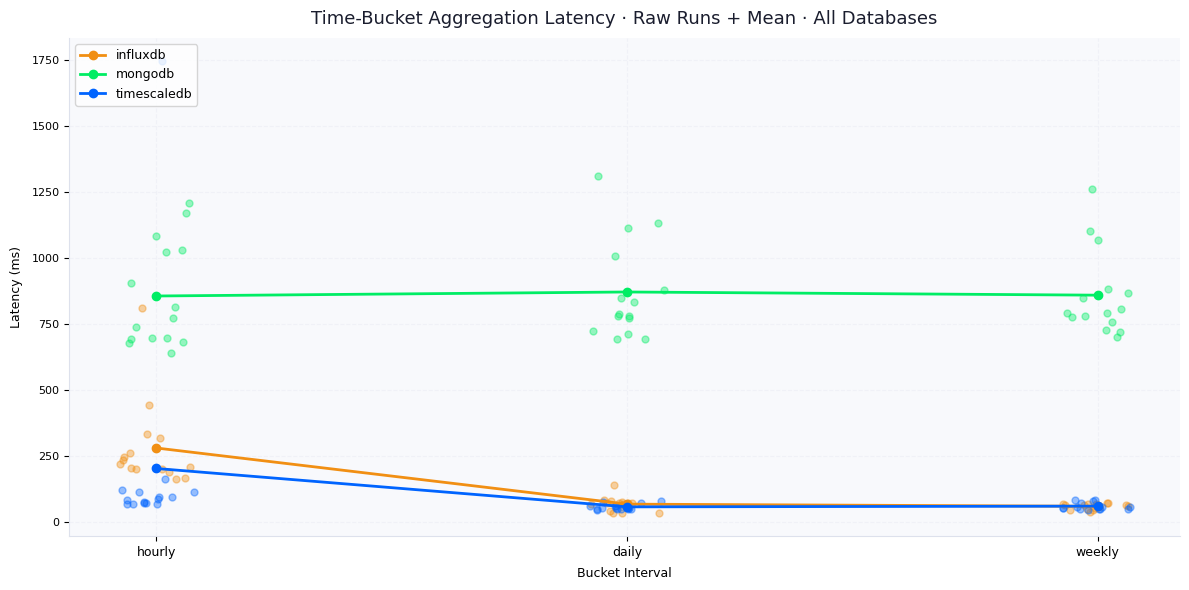

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

x_positions = {b: i for i, b in enumerate(buckets_present)}

for db in db_systems:
    sub = df[df['database_system'] == db]

    for b in buckets_present:
        vals = sub[sub['bucket_interval'] == b]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[b]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['bucket_interval'] == b]['elapsed_ms'].mean() if b in sub['bucket_interval'].values else np.nan
        for b in buckets_present
    ]
    ax.plot(range(len(buckets_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_xticks(range(len(buckets_present)))
ax.set_xticklabels(buckets_present, fontsize=9)
ax.set_xlabel('Bucket Interval', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Time-Bucket Aggregation Latency · Raw Runs + Mean · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Same Chart, Log Scale

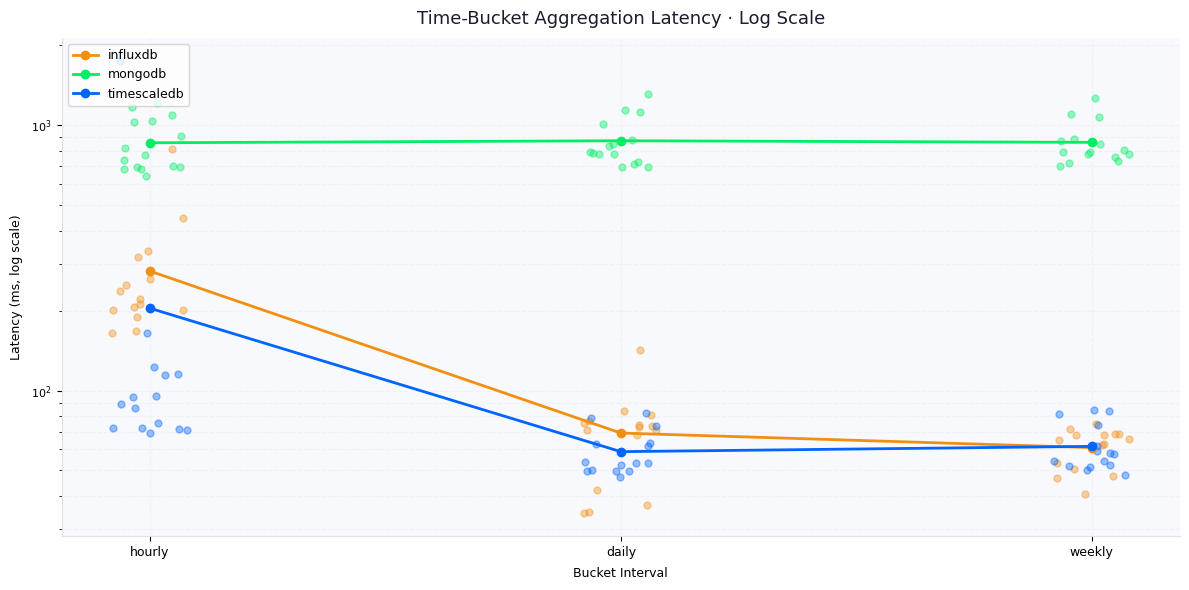

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for db in db_systems:
    sub = df[df['database_system'] == db]

    for b in buckets_present:
        vals = sub[sub['bucket_interval'] == b]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[b]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['bucket_interval'] == b]['elapsed_ms'].mean() if b in sub['bucket_interval'].values else np.nan
        for b in buckets_present
    ]
    ax.plot(range(len(buckets_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_yscale('log')
ax.set_xticks(range(len(buckets_present)))
ax.set_xticklabels(buckets_present, fontsize=9)
ax.set_xlabel('Bucket Interval', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms, log scale)', fontsize=9, labelpad=6)
ax.set_title('Time-Bucket Aggregation Latency · Log Scale', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Grouped Bars, Per Parameter (Hourly Bucket)

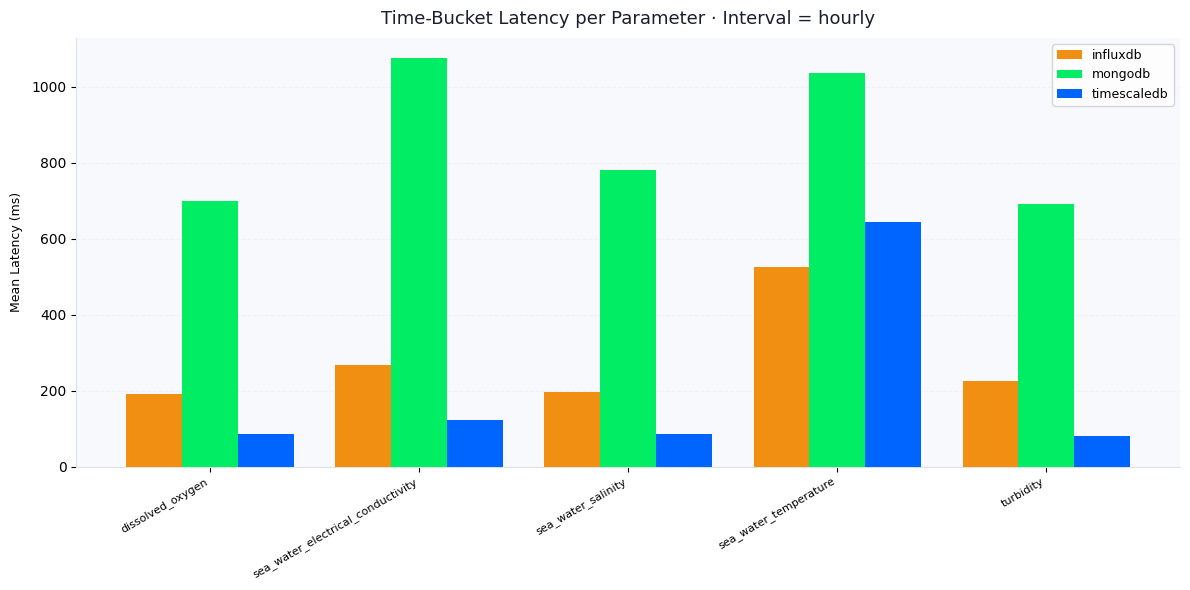

In [16]:
BUCKET_TO_PLOT = "hourly"

sub = df[df['bucket_interval'] == BUCKET_TO_PLOT]
parameters = sorted(sub['parameter'].unique())

x = np.arange(len(parameters))
n_dbs = len(db_systems)
bar_width = 0.8 / n_dbs

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for i, db in enumerate(db_systems):
    means = [
        sub[(sub['database_system'] == db) & (sub['parameter'] == p)]['elapsed_ms'].mean()
        for p in parameters
    ]
    offsets = x + i * bar_width - (n_dbs - 1) * bar_width / 2
    ax.bar(offsets, means, width=bar_width, color=db_color[db], label=db, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(parameters, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('Mean Latency (ms)', fontsize=9, labelpad=6)
ax.set_title(f'Time-Bucket Latency per Parameter · Interval = {BUCKET_TO_PLOT}', fontsize=13, pad=10, color='#1a1d2e')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()